# Reading the scraped data from the database

In [2]:
import sqlite3
import pandas as pd
import seaborn as sns

conn = sqlite3.connect("data/connections.db")

puzzles = pd.read_sql("SELECT * FROM puzzles", conn)
groups = pd.read_sql("SELECT * FROM groups", conn)
words = pd.read_sql("SELECT * FROM words", conn)

conn.close()

print("Puzzles: ")
print(puzzles.head())
print("Groups: ")
print(groups.head())
print("Words: ")
print(words.head())

Puzzles: 
  puzzle_date puzzle_number                                                url
0  2023-06-12          None  https://www.fiveletterwords.io/connections/202...
1  2023-06-13          None  https://www.fiveletterwords.io/connections/202...
2  2023-06-14          None  https://www.fiveletterwords.io/connections/202...
3  2023-06-15          None  https://www.fiveletterwords.io/connections/202...
4  2023-06-16          None  https://www.fiveletterwords.io/connections/202...
Groups: 
  puzzle_date puzzle_number   color       category
0  2023-06-12          None  yellow    WET WEATHER
1  2023-06-12          None   green      NBA TEAMS
2  2023-06-12          None    blue  KEYBOARD KEYS
3  2023-06-12          None  purple    PALINDROMES
4  2023-06-13          None  yellow       FOOTWEAR
Words: 
  puzzle_date puzzle_number   color     category  position   word
0  2023-06-12          None  yellow  WET WEATHER         1   HAIL
1  2023-06-12          None  yellow  WET WEATHER         2   

# Finding the length of the words in the database

In [10]:
lengths = [len(w) for w in words["word"]]
words["word_length"] = lengths

In [14]:
print(words["color"][:16])

0     yellow
1     yellow
2     yellow
3     yellow
4      green
5      green
6      green
7      green
8       blue
9       blue
10      blue
11      blue
12    purple
13    purple
14    purple
15    purple
Name: color, dtype: object


In [18]:
def Difficulty_map(data):
    difficulty = {
        "green": 1,
        "yellow": 2,
        "blue": 3,
        "purple": 4
    }

    data["difficulty"] = data["color"].map(difficulty)
    return data


words = Difficulty_map(words)
words.head()

,puzzle_date,puzzle_number,color,category,position,word,word_length,difficulty
0,2023-06-12,None,yellow,WET WEATHER,1,HAIL,4,2
1,2023-06-12,None,yellow,WET WEATHER,2,RAIN,4,2
2,2023-06-12,None,yellow,WET WEATHER,3,SLEET,5,2
3,2023-06-12,None,yellow,WET WEATHER,4,SNOW,4,2
4,2023-06-12,None,green,NBA TEAMS,1,BUCKS,5,1


In [19]:
words.head(16)

,puzzle_date,puzzle_number,color,category,position,word,word_length,difficulty
0,2023-06-12,None,yellow,WET WEATHER,1,HAIL,4,2
1,2023-06-12,None,yellow,WET WEATHER,2,RAIN,4,2
2,2023-06-12,None,yellow,WET WEATHER,3,SLEET,5,2
3,2023-06-12,None,yellow,WET WEATHER,4,SNOW,4,2
4,2023-06-12,None,green,NBA TEAMS,1,BUCKS,5,1
5,2023-06-12,None,green,NBA TEAMS,2,HEAT,4,1
6,2023-06-12,None,green,NBA TEAMS,3,JAZZ,4,1
7,2023-06-12,None,green,NBA TEAMS,4,NETS,4,1
8,2023-06-12,None,blue,KEYBOARD KEYS,1,OPTION,6,3
9,2023-06-12,None,blue,KEYBOARD KEYS,2,RETURN,6,3


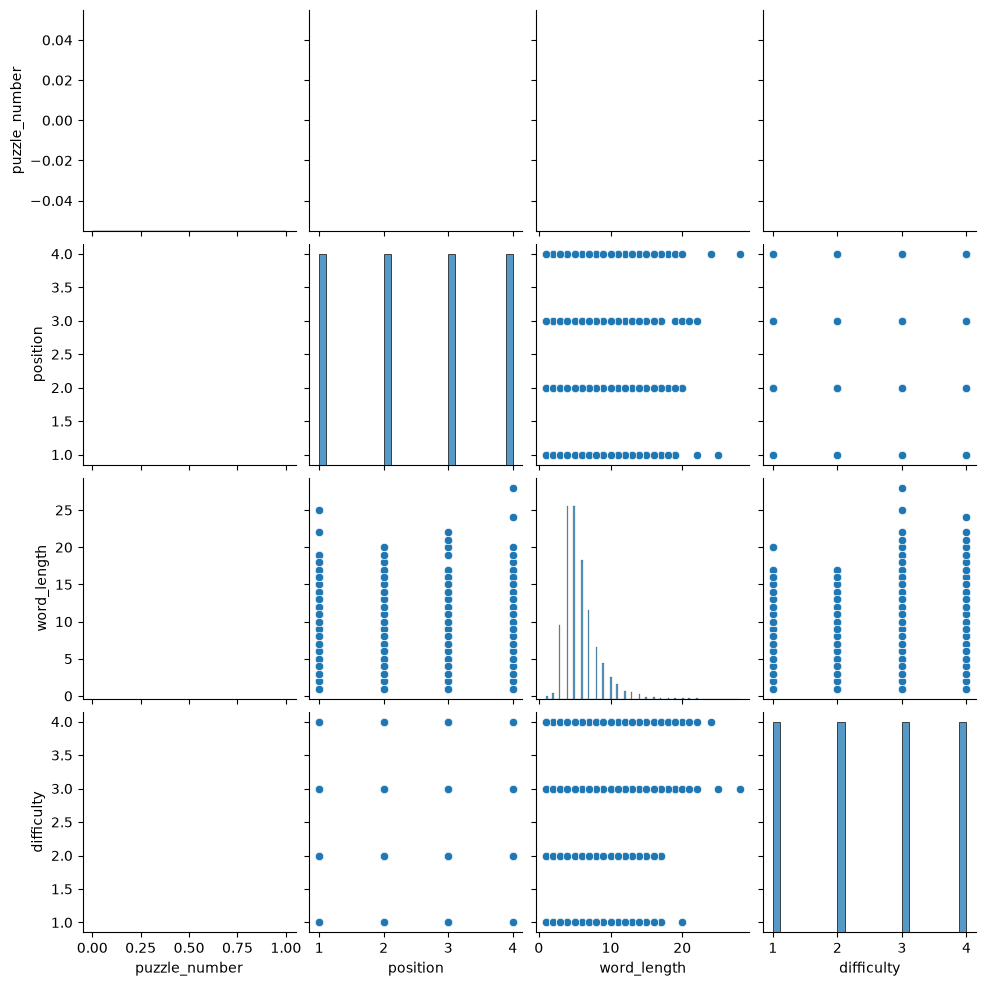

In [20]:
sns.pairplot(words)